
---
date: "2026-09-08"
date-modified: last-modified
format:
  html:
    toc: true
---



# Boosting and Additive Tree Models

Like [Bagging](bagging-and-random-forests.ipynb) and [Random Forests](bagging-and-random-forests.ipynb), **Boosting** is a powerful ensemble method that combines a collection of simple decision trees into a single consensus model with superior predictive accuracy. However, Boosting operates under a fundamentally different architectural paradigm.

In Bagging and Random Forests, large, deep trees are grown **in parallel and independently** on bootstrapped copies of the data, with the primary objective of reducing **variance** through unweighted averaging. In Boosting, trees are grown **sequentially**: each tree is trained on the original dataset using information left behind by previously grown trees, with the primary objective of systematically reducing **bias** and training error through **slow residual learning**.

---

## 1\. The Boosting Philosophy: Sequential Learning on Residuals

::: {.callout-note}
## Intuition: Learn Slowly, Attack the Residuals
Fitting a single large, deep decision tree directly to the response $Y$ amounts to "fitting the data hard," which captures sample noise and leads to severe overfitting. 

Boosting adopts the opposite philosophy: **learn slowly**. The algorithm fits a very simple, shallow tree to the current residuals (unexplained errors) of the model rather than the target $Y$. The newly fitted tree is then scaled by a small shrinkage parameter $\lambda \ll 1$ and added into the existing ensemble, gently nudging the model in the direction that corrects its weaknesses. This iterative refinement allows trees of varying shapes to target distinct regions of the residual space.
:::

### 1.1\. Structural Comparison with Bagging

The core distinctions between Bagging and Boosting are:

1. **Tree Independence:** In Bagging, tree $b$ has no dependency on tree $b-1$. In Boosting, tree $b$ depends explicitly on the errors of the ensemble formed by trees $1, \dots, b-1$.
2. **Data Resampling:** Bagging relies on bootstrap resampling with replacement. Boosting uses the original dataset throughout, modifying only the target response (the residuals) at each iteration.
3. **Tree Complexity:** Bagging requires deep, unpruned trees (low bias, high variance). Boosting requires very shallow trees or **decision stumps** (high bias, low variance).



## 2\. Boosting Algorithm for Regression Trees

Let $\mathcal{D} = \{(\mathbf{x}_i, y_i)\}_{i=1}^n$ be the training dataset with continuous response $y_i \in \mathbb{R}$.

::: {#def-boosting-regression}
## Boosting Algorithm for Regression Trees
The sequential boosting procedure is defined as follows:

1. **Initialization:** Set the initial ensemble prediction to zero, and initialize the residuals to the observed responses:
   $$
   \hat{f}(\mathbf{x}) = 0, \quad r_i = y_i \quad \forall i \in \{1, 2, \dots, n\}
   $$
2. **Sequential Iteration:** For $b = 1, 2, \dots, B$, repeat:
   a. Fit a decision tree $\hat{f}^b(\mathbf{x})$ with $d$ splits ($d+1$ terminal leaves) to the training data using the current residuals as the response: $(\mathbf{x}_i, r_i)_{i=1}^n$.
   b. Update the cumulative ensemble model $\hat{f}(\mathbf{x})$ by adding a shrunken version of the new tree:
      $$
      \hat{f}(\mathbf{x}) \leftarrow \hat{f}(\mathbf{x}) + \lambda \hat{f}^b(\mathbf{x})
      $$
   c. Update the residuals for all training observations:
      $$
      r_i \leftarrow r_i - \lambda \hat{f}^b(\mathbf{x}_i)
      $$
3. **Output:** The final boosted ensemble model is the weighted linear sum of all $B$ base trees:
   $$
   \hat{f}(\mathbf{x}) = \sum_{b=1}^B \lambda \hat{f}^b(\mathbf{x})
   $$
:::

::: {.callout-note}
## Intuition: Gradient Descent in Function Space
Notice that the negative gradient of the squared error loss $L(y, \hat{f}) = \frac{1}{2}(y - \hat{f})^2$ with respect to the prediction $\hat{f}$ is:
$$
-\frac{\partial L(y_i, \hat{f}(\mathbf{x}_i))}{\partial \hat{f}(\mathbf{x}_i)} = y_i - \hat{f}(\mathbf{x}_i) = r_i
$$
Thus, fitting a tree to the residuals $r_i$ corresponds to fitting a tree to the negative gradient of the loss function, and the update $\hat{f} \leftarrow \hat{f} + \lambda \hat{f}^b$ is a functional [gradient descent](gradient-descent-and-variants.ipynb) step with step size (learning rate) $\lambda$.
:::



## 3\. Key Hyperparameters & Inductive Bias

Boosting has three primary tuning parameters that govern its bias-variance trade-off:

### 3.1\. The Number of Trees ($B$)

::: {.callout-warning}
## Overfitting Risk with Large $B$
In Bagging and Random Forests, choosing an arbitrarily large number of trees $B$ does not cause overfitting; the test error settles down monotonically. 

**In Boosting, this is not true:** Because each tree iteratively targets the remaining residuals, a sufficiently large $B$ will eventually allow the ensemble to fit the noise in the training residuals, driving training error to zero while causing test error to rise. Cross-validation is strictly required to select the optimal stopping point $B^*$.
:::

### 3.2\. The Shrinkage Parameter ($\lambda$)

The parameter $\lambda > 0$ is a small positive scalar (typically $\lambda = 0.01$ or $0.001$) acting as the learning rate.

* It scales down the contribution of each individual tree, preventing any single dominant split from overly determining the trajectory of the ensemble.
* A smaller $\lambda$ provides superior regularized performance across complex landscapes, but requires a correspondingly larger number of trees $B$ to achieve convergence.

### 3.3\. Interaction Depth ($d$) & Decision Stumps

The parameter $d$ controls the number of splits in each individual tree $\hat{f}^b$. A tree with $d$ splits contains $d + 1$ terminal nodes and can involve at most $d$ distinct variables.

::: {#thm-boosting-stumps-additive}
## Decision Stumps ($d = 1$) and Additive Models
When $d = 1$, each tree is a **decision stump**, consisting of a single internal split on a single predictor variable. In this setting, the boosted ensemble fits an **additive model**:

$$
f(\mathbf{X}) = \sum_{j=1}^p f_j(X_j)
$$

where each component $f_j(X_j)$ is a piecewise constant step function of the single coordinate $X_j$.
:::

::: {.callout-tip collapse="true"}
## Proof of the Additive Form for Decision Stumps
Let $v(b) \in \{1, \dots, p\}$ denote the predictor variable selected by the single split of stump $\hat{f}^b$. Because stump $\hat{f}^b$ splits on only variable $X_{v(b)}$, its prediction depends strictly on coordinate $X_{v(b)}$:

$$
\hat{f}^b(\mathbf{x}) = g_b(X_{v(b)})
$$

where $g_b: \mathbb{R} \to \mathbb{R}$ is a step function. The boosted ensemble model is:

$$
\hat{f}(\mathbf{x}) = \sum_{b=1}^B \lambda \hat{f}^b(\mathbf{x}) = \sum_{b=1}^B \lambda g_b(X_{v(b)})
$$

Grouping the summation by predictor index $j \in \{1, \dots, p\}$:

$$
\hat{f}(\mathbf{x}) = \sum_{j=1}^p \left( \sum_{b: v(b) = j} \lambda g_b(X_j) \right)
$$

Defining $f_j(X_j) \equiv \sum_{b: v(b) = j} \lambda g_b(X_j)$, we obtain:

$$
\hat{f}(\mathbf{x}) = \sum_{j=1}^p f_j(X_j)
$$

which is the exact definition of a generalized additive model without interaction terms. $\blacksquare$
:::

::: {.callout-note}
## Intuition: Interaction Depth Governs Interaction Order
More generally, $d$ is termed the **interaction depth**. Because a tree with $d$ splits can split on at most $d$ distinct variables along any root-to-leaf branch, it models interactions up to order $d$. If $d = 2$, pairs of variables $(X_j, X_k)$ can interact. Often, simple stumps ($d=1$) or shallow trees ($d=2$ to $4$) yield remarkable empirical performance while preventing high-order noise overfitting.
:::



## 4\. Comparative Synthesis of Tree-Based Ensemble Methods

The table below synthesizes the fundamental properties across the family of tree-based methods:

| Characteristic | Single Decision Tree | Bagging | Random Forest | Boosting |
| :--- | :--- | :--- | :--- | :--- |
| **Ensemble Paradigm** | None (Single tree) | Parallel independent | Parallel independent | Sequential dependent |
| **Data Sampling** | Full dataset $\mathcal{D}$ | Bootstrap with replacement | Bootstrap with replacement | Full dataset $\mathcal{D}$ (modified targets) |
| **Candidate Features per Split** | All $p$ predictors | All $p$ predictors | Random subset $m \approx \sqrt{p}$ | All $p$ predictors |
| **Base Tree Depth** | Pruned or constrained | Deep, unpruned | Deep, unpruned | Shallow (often stumps $d=1$) |
| **Aggregation Rule** | Identity | Arithmetic Mean / Majority Vote | Arithmetic Mean / Majority Vote | Sum of shrunken trees: $\sum \lambda \hat{f}^b$ |
| **Overfitting with Large $B$** | N/A | Non-overfitting (stabilizes) | Non-overfitting (stabilizes) | Overfits if $B$ is too large (requires CV) |
| **Primary Error Mechanism** | High variance | Variance reduction | Variance reduction (via decorrelation) | Bias reduction (via residual pursuit) |
| **Interpretability** | High (Visual diagram) | Low (Variable importance) | Low (Variable importance) | Moderate (Additive model if $d=1$) |

---

## 5\. Simulation: Step-by-Step Residual Fitting with Decision Stumps

Below, we simulate:
1. How a sequence of 1D decision stumps ($d=1$) iteratively approximates a continuous target function $y = \sin(x) + \epsilon$ by fitting successive residuals.
2. Training vs. Test error progression as $B$ increases, contrasting the stability of Random Forests against the eventual overfitting of unregularized Boosting.


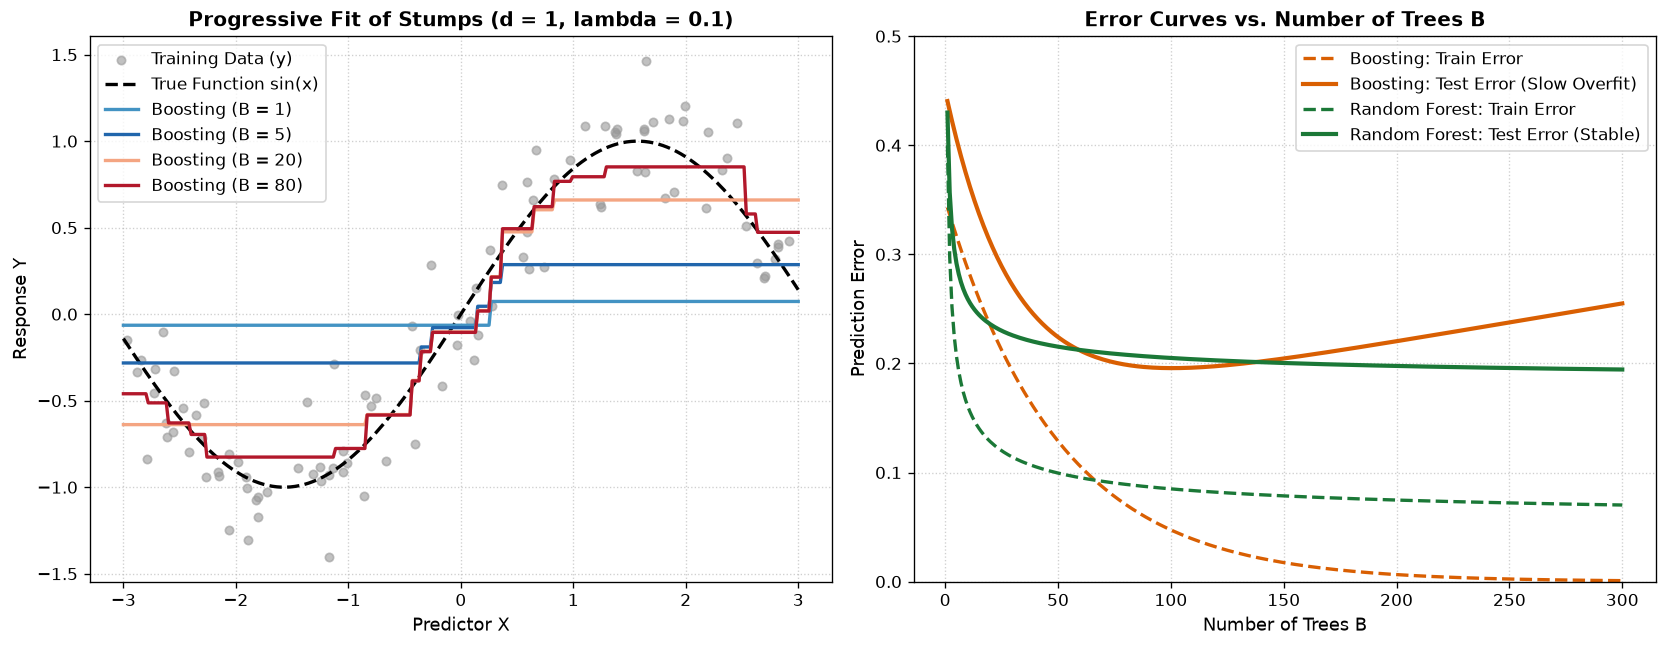

In [1]:

import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), dpi=120)

# -----------------------------------------------------
# Panel 1: Step-by-Step Boosting with Decision Stumps
# -----------------------------------------------------
ax1 = axes[0]
np.random.seed(42)
x = np.sort(np.random.uniform(-3, 3, 100))
y_true = np.sin(x)
y = y_true + np.random.normal(0, 0.25, size=len(x))

# Manual 1D stump fitting on residuals
def fit_stump(x_vals, residuals):
    best_rss = float('inf')
    best_s = 0.0
    best_c1, best_c2 = 0.0, 0.0
    for s in x_vals[1:-1]:
        left = residuals[x_vals < s]
        right = residuals[x_vals >= s]
        if len(left) == 0 or len(right) == 0:
            continue
        c1 = np.mean(left)
        c2 = np.mean(right)
        rss = np.sum((left - c1)**2) + np.sum((right - c2)**2)
        if rss < best_rss:
            best_rss = rss
            best_s = s
            best_c1 = c1
            best_c2 = c2
    return best_s, best_c1, best_c2

# Run 80 boosting iterations
lam = 0.1
f_pred = np.zeros_like(y)
res = y.copy()
x_dense = np.linspace(-3, 3, 300)
f_dense = np.zeros_like(x_dense)

stamps = [1, 5, 20, 80]
curves = {}

for b in range(1, 81):
    s, c1, c2 = fit_stump(x, res)
    stump_pred = np.where(x < s, c1, c2)
    stump_dense = np.where(x_dense < s, c1, c2)
    
    f_pred += lam * stump_pred
    f_dense += lam * stump_dense
    res -= lam * stump_pred
    
    if b in stamps:
        curves[b] = f_dense.copy()

ax1.scatter(x, y, color='#999999', alpha=0.6, s=25, label='Training Data (y)')
ax1.plot(x_dense, np.sin(x_dense), 'k--', linewidth=2, label='True Function sin(x)')

colors = ['#4393c3', '#2166ac', '#f4a582', '#b2182b']
for (b, curve), col in zip(curves.items(), colors):
    ax1.plot(x_dense, curve, label=f'Boosting (B = {b})', color=col, linewidth=2)

ax1.set_title("Progressive Fit of Stumps (d = 1, lambda = 0.1)", fontsize=12, fontweight='bold')
ax1.set_xlabel("Predictor X", fontsize=11)
ax1.set_ylabel("Response Y", fontsize=11)
ax1.legend(frameon=True, facecolor='white', loc='upper left')
ax1.grid(True, linestyle=':', alpha=0.6)

# -----------------------------------------------------
# Panel 2: Error Trajectories: Boosting vs. Random Forest
# -----------------------------------------------------
ax2 = axes[1]
B_range = np.linspace(1, 300, 300)

rf_train = 0.05 + 0.35 / np.sqrt(B_range)
rf_test = 0.18 + 0.25 / np.sqrt(B_range)

boost_train = 0.35 * np.exp(-B_range / 50)
boost_test = 0.15 + 0.30 * np.exp(-B_range / 30) + 0.00035 * B_range

ax2.plot(B_range, boost_train, color='#d95f02', linestyle='--', linewidth=2, label='Boosting: Train Error')
ax2.plot(B_range, boost_test, color='#d95f02', linewidth=2.5, label='Boosting: Test Error (Slow Overfit)')
ax2.plot(B_range, rf_train, color='#1b7837', linestyle='--', linewidth=2, label='Random Forest: Train Error')
ax2.plot(B_range, rf_test, color='#1b7837', linewidth=2.5, label='Random Forest: Test Error (Stable)')

ax2.set_title("Error Curves vs. Number of Trees B", fontsize=12, fontweight='bold')
ax2.set_xlabel("Number of Trees B", fontsize=11)
ax2.set_ylabel("Prediction Error", fontsize=11)
ax2.set_ylim(0, 0.5)
ax2.legend(frameon=True, facecolor='white', loc='upper right')
ax2.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()
